# Preprocessing v1
Preprocessing minimal sesuai karakteristik data dari EDA.
Tidak ada manipulasi data yang tidak justified — data dibiarkan as-is kecuali yang benar-benar invalid.

In [1]:
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import pickle

%matplotlib inline

In [2]:
from config_v1 import DATA_DIR, BATCH_FILES, OUTPUT_DIR, TRAIN_SIZE, VAL_SIZE, TEST_SIZE

## 1. Load Semua Batch

In [3]:
def load_cell(f, batch, idx):
    cycle_life_val = f[batch['cycle_life'][idx][0]][0][0]

    summary_group = f[batch['summary'][idx][0]]
    summary = {
        'QDischarge': summary_group['QDischarge'][0][1:],
        'QCharge':    summary_group['QCharge'][0][1:],
        'IR':         summary_group['IR'][0][1:],
        'Tavg':       summary_group['Tavg'][0][1:],
        'cycle':      summary_group['cycle'][0][1:],
        'chargetime': summary_group['chargetime'][0][1:],
    }

    cycles_group = f[batch['cycles'][idx][0]]
    n_cycles = cycles_group['V'].shape[0]
    cycles = []
    for c in range(1, n_cycles):
        V = f[cycles_group['V'][c][0]][:].flatten()
        I = f[cycles_group['I'][c][0]][:].flatten()
        T = f[cycles_group['T'][c][0]][:].flatten()
        t = f[cycles_group['t'][c][0]][:].flatten()
        cycles.append({'V': V, 'I': I, 'T': T, 't': t})

    return {
        'cycle_life': cycle_life_val,
        'summary': summary,
        'cycles': cycles,
    }


all_cells = []
batch_paths = [os.path.join(DATA_DIR, f) for f in BATCH_FILES]

for batch_idx, path in enumerate(batch_paths):
    f = h5py.File(path, 'r')
    batch = f['batch']
    n_cells = batch['cycle_life'].shape[0]
    for i in range(n_cells):
        cell = load_cell(f, batch, i)
        cell['batch'] = f'batch_{batch_idx + 1}'
        cell['cell_id'] = f'b{batch_idx + 1}_c{i}'
        all_cells.append(cell)
    f.close()
    print(f'Batch {batch_idx + 1}: {n_cells} sel loaded')

print(f'\nTotal sebelum filter: {len(all_cells)} sel')

Batch 1: 46 sel loaded
Batch 2: 48 sel loaded
Batch 3: 46 sel loaded

Total sebelum filter: 140 sel


## 2. Filter — Drop Sel dengan cycle_life Missing atau NaN

In [4]:
before = len(all_cells)
all_cells = [c for c in all_cells if not np.isnan(c['cycle_life'])]
after = len(all_cells)
print(f'Drop missing cycle_life: {before - after} sel')
print(f'Sisa: {after} sel')

Drop missing cycle_life: 2 sel
Sisa: 138 sel


## 3. Verifikasi Distribusi Setelah Filter

In [5]:
cycle_lives = [c['cycle_life'] for c in all_cells]
batches = [c['batch'] for c in all_cells]

df = pd.DataFrame({'cycle_life': cycle_lives, 'batch': batches})
print(df.groupby('batch')['cycle_life'].describe())
print(f'\nTotal: {len(df)} sel')
print(f'Range: {df["cycle_life"].min():.0f} - {df["cycle_life"].max():.0f}')

         count         mean         std    min     25%     50%      75%  \
batch                                                                     
batch_1   46.0   844.717391  184.629198  534.0  703.25   858.5   914.25   
batch_2   48.0   494.708333  141.111388  148.0  461.00   483.0   503.75   
batch_3   44.0  1059.659091  313.869692  541.0  828.00  1005.5  1155.25   

            max  
batch            
batch_1  1227.0  
batch_2  1061.0  
batch_3  1935.0  

Total: 138 sel
Range: 148 - 1935


## 4. Train / Val / Test Split
Sesuai paper: 41 train, 43 val, 40 test.
Split dilakukan secara sequential per batch mengikuti konvensi Severson et al.

In [6]:
np.random.seed(42)
indices = np.arange(len(all_cells))
np.random.shuffle(indices)

train_idx = indices[:TRAIN_SIZE]
val_idx   = indices[TRAIN_SIZE:TRAIN_SIZE + VAL_SIZE]
test_idx  = indices[TRAIN_SIZE + VAL_SIZE:TRAIN_SIZE + VAL_SIZE + TEST_SIZE]

train_cells = [all_cells[i] for i in train_idx]
val_cells   = [all_cells[i] for i in val_idx]
test_cells  = [all_cells[i] for i in test_idx]

print(f'Train : {len(train_cells)} sel')
print(f'Val   : {len(val_cells)} sel')
print(f'Test  : {len(test_cells)} sel')
print(f'Total : {len(train_cells) + len(val_cells) + len(test_cells)} sel')

Train : 41 sel
Val   : 43 sel
Test  : 40 sel
Total : 124 sel


## 5. Verifikasi Distribusi Split

Train: mean=832.7, std=328.6, min=459, max=1836
Val: mean=799.3, std=333.1, min=148, max=1935
Test: mean=737.2, std=276.4, min=209, max=1267


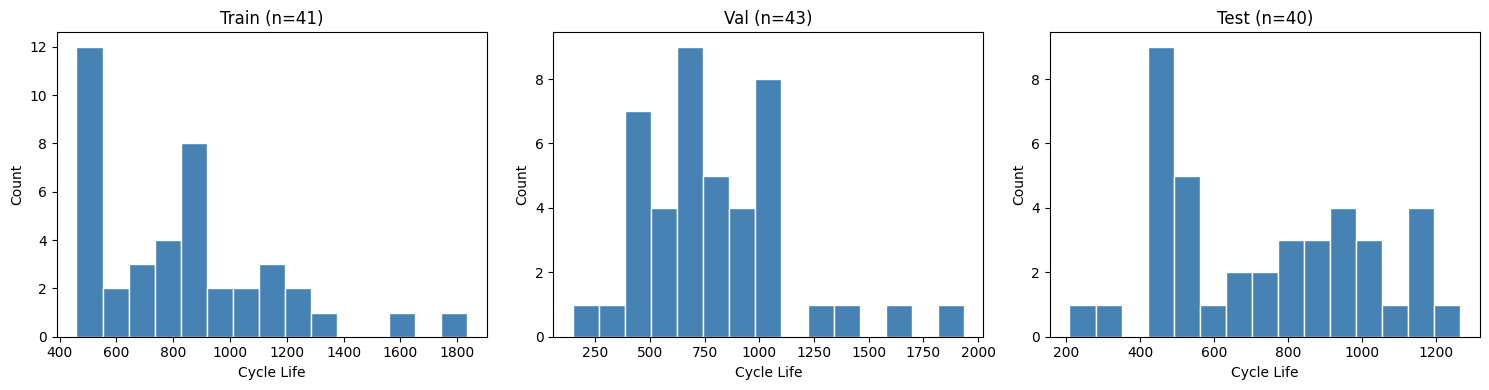

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
splits = {'Train': train_cells, 'Val': val_cells, 'Test': test_cells}

for ax, (name, cells) in zip(axes, splits.items()):
    lives = [c['cycle_life'] for c in cells]
    ax.hist(lives, bins=15, color='steelblue', edgecolor='white')
    ax.set_title(f'{name} (n={len(cells)})')
    ax.set_xlabel('Cycle Life')
    ax.set_ylabel('Count')
    print(f'{name}: mean={np.mean(lives):.1f}, std={np.std(lives):.1f}, min={np.min(lives):.0f}, max={np.max(lives):.0f}')

plt.tight_layout()
plt.show()

## 6. Simpan Hasil Preprocessing

In [8]:
os.makedirs(OUTPUT_DIR, exist_ok=True)

splits_data = {
    'train': train_cells,
    'val':   val_cells,
    'test':  test_cells,
}

output_path = os.path.join(OUTPUT_DIR, 'preprocessed_v1.pkl')
with open(output_path, 'wb') as f:
    pickle.dump(splits_data, f)

print(f'Saved to {output_path}')

Saved to ../../outputs/v1\preprocessed_v1.pkl


## 7. Sanity Check — Sample Cycle Data dari 1 Sel

In [9]:
sample = train_cells[0]
print(f'Cell ID    : {sample["cell_id"]}')
print(f'Cycle life : {sample["cycle_life"]}')
print(f'Jumlah cycles loaded: {len(sample["cycles"])}')
print(f'Summary QDischarge shape: {sample["summary"]["QDischarge"].shape}')

cycle_10 = sample['cycles'][9]
print(f'\nCycle 10:')
print(f'  V shape: {cycle_10["V"].shape}, range: [{cycle_10["V"].min():.2f}, {cycle_10["V"].max():.2f}]')
print(f'  I shape: {cycle_10["I"].shape}, range: [{cycle_10["I"].min():.2f}, {cycle_10["I"].max():.2f}]')
print(f'  T shape: {cycle_10["T"].shape}, range: [{cycle_10["T"].min():.2f}, {cycle_10["T"].max():.2f}]')

Cell ID    : b2_c43
Cycle life : 462.0
Jumlah cycles loaded: 486
Summary QDischarge shape: (486,)

Cycle 10:
  V shape: (1232,), range: [2.00, 3.60]
  I shape: (1232,), range: [-4.00, 6.01]
  T shape: (1232,), range: [29.97, 36.79]
